
# 🐣 Human-Embryo *Phase Classifier* — End-to-End Notebook  

This notebook trains a deep network that maps a **single time-lapse frame**  
to its *morphokinetic phase* (`t2`, `t3`, …, `tB`).

## Paths

```python
PROJECT_ROOT            = Path("..")
ANNOT_DIR               = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'
```


In [1]:

# @title 🔧 Install & Imports

import random, re, math, json, os, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt


In [2]:
# @title 📁 Paths & Device
PROJECT_ROOT        = Path("..").resolve()
FOCAL_PLANES        = ['F0'] #['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']
DATA_ROOTS          = {fp: PROJECT_ROOT / 'data' / 'embryo_dataset_silver' / fp for fp in FOCAL_PLANES}
ANNOT_DIR           = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

# Verify all focal plane directories exist
for fp, dr in DATA_ROOTS.items():
    assert dr.is_dir(), f"{dr} not found"
assert ANNOT_DIR.is_dir(), f"{ANNOT_DIR} not found"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
print(f"Focal planes: {FOCAL_PLANES}")


Running on cuda
Focal planes: ['F0']


In [3]:
# @title 🚫 Embryo Exclusion List
EXCLUDE_EMBRYOS = {
    "BJ492-8",
    "ALR493-6"
}

In [4]:
# @title ⚙️ Helpers

PHASES = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB"
]

# Merge extremely rare terminal class into tEB
PHASE_ALIAS = {
    "tHB": "tEB",
}

PHASE2IDX = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE = {i: p for p, i in PHASE2IDX.items()}
NUM_CLASSES = len(PHASES)

def normalize_phase(phase: str):
    p = str(phase).strip()
    return PHASE_ALIAS.get(p, p)

def extract_frame_idx(name: str):
    m = re.search(r"(\d+)\.jpeg$", name)
    return int(m.group(1)) if m else None

def index_frames(folder: Path):
    mapping = {}
    for fp in folder.glob("*.jpeg"):
        m = re.search(r"(\d+)\.jpeg$", fp.name)
        if m:
            mapping[int(m.group(1))] = fp
    return mapping


In [5]:
# @title 🗄️ PhaseDataset (filters empty frames)

FRAMES_PER_PHASE = 7      # None → keep all

class PhaseDataset(Dataset):
    def __init__(self, embryo_ids, transform, focal_planes=None, frames_per_phase=10):
        self.transform = transform
        self.focal_planes = focal_planes or list(DATA_ROOTS.keys())
        self.samples   = []           # [(img_path, label_idx), …]

        for eid in tqdm(embryo_ids):
            csv_path = ANNOT_DIR / f"{eid}_phases.csv"
            if not csv_path.is_file():      # skip missing
                print(f"Warning: missing annotation for {eid}, skipping")
                continue

            df = pd.read_csv(csv_path, header=None,
                             names=["phase", "start", "end"])

            # Process each focal plane for this embryo
            for fp in self.focal_planes:
                data_root = DATA_ROOTS[fp]
                frame2path = index_frames(data_root / eid)

                for phase, start, end in df.itertuples(index=False):
                    phase = normalize_phase(phase)
                    if phase not in PHASE2IDX:          # unknown label → skip
                        continue

                    # ---- subsample frames ----------------------------------
                    if frames_per_phase and (end - start + 1) > frames_per_phase:
                        sel = np.linspace(start, end, frames_per_phase, dtype=int)
                    else:
                        sel = range(start, end + 1)

                    paths = [frame2path.get(f) for f in sel if frame2path.get(f)]

                    lbl = PHASE2IDX[phase]
                    for p in paths:
                        self.samples.append((p, lbl))

        print(f"Got {len(self.samples):,} frames from {len(self.focal_planes)} focal planes")
        self.num_classes = NUM_CLASSES

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("L")
        return self.transform(img), torch.tensor(label)


In [6]:
# @title 🧰 Transforms & Data Split
MAX_EMBRYOS = None          # 25 for a quick run

IMG_SIZE = 256
# Common transforms for all sets (resize + normalize)
base_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),  # normalize all sets consistently
])

# Additional augmentations only for training
train_aug = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ColorJitter(
        brightness=0.12,
        contrast=0.12,
    ),
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3,3), sigma=(0.1, 0.6))
    ], p=0.1),
    v2.RandomAffine(
        degrees=180,
        translate=(0.015, 0.015),
        scale=(0.9, 1.1),
    ),
])

# Training pipeline: base transforms -> augmentations -> normalize
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    train_aug,
    T.Normalize([0.5], [0.5])
])

# Val/Test pipeline: just the base transforms including normalization
val_tfm = base_tfm

In [7]:
# embryo-level split
all_embryos = sorted([p.name for p in DATA_ROOTS[FOCAL_PLANES[0]].iterdir() if p.is_dir()
                      and p.name not in EXCLUDE_EMBRYOS])

random.seed(42)
np.random.seed(42)
random.shuffle(all_embryos)

# respect MAX_EMBRYOS
if MAX_EMBRYOS is not None:
    assert MAX_EMBRYOS >= 3, "Need ≥3 embryos to form train/val/test"
    all_embryos = all_embryos[:MAX_EMBRYOS]

n_val = max(1, int(0.10*len(all_embryos)))
n_test = max(1, int(0.10*len(all_embryos)))
val_embryos = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val+n_test]
train_embryos = all_embryos[n_val+n_test:]

# ✅ Ensure class-wise coverage in VAL/TEST by pulling missing-phase embryos from TRAIN

# Cache: embryo -> set(phases present in its CSV)
def load_embryo_phases(eid: str):
    csv_path = ANNOT_DIR / f"{eid}_phases.csv"
    if not csv_path.is_file():
        return set()
    df = pd.read_csv(csv_path, header=None, names=["phase", "start", "end"])
    phases = set()
    for p in df["phase"].tolist():
        p_norm = normalize_phase(p)
        if p_norm in PHASE2IDX:
            phases.add(p_norm)
    return phases

embryo2phases = {eid: load_embryo_phases(eid) for eid in all_embryos}

def split_phase_coverage(eids):
    covered = set()
    for eid in eids:
        covered |= embryo2phases.get(eid, set())
    return covered

def enforce_coverage_for(split_name, split_list, train_list):
    added = []
    covered = split_phase_coverage(split_list)
    for phase in PHASES:
        if phase not in covered:
            # find a donor embryo in TRAIN that has this phase
            donor = next((eid for eid in train_list
                          if phase in embryo2phases.get(eid, set())
                          and eid not in split_list), None)
            if donor is not None:
                train_list.remove(donor)
                split_list.append(donor)
                added.append((phase, donor))
                covered |= embryo2phases.get(donor, set())
            else:
                print(f"[warn] No available TRAIN embryo with phase '{phase}' to add to {split_name}.")
    if added:
        print(f"[info] Added to {split_name}: " + ", ".join([f"{ph}->{eid}" for ph, eid in added]))
    else:
        print(f"[info] {split_name} already covers all phases.")

# Apply to VAL then TEST (only pull from TRAIN)
enforce_coverage_for("VAL",  val_embryos,  train_embryos)
enforce_coverage_for("TEST", test_embryos, train_embryos)

# (Optional) quick sanity check
for name, split in [("TRAIN", train_embryos), ("VAL", val_embryos), ("TEST", test_embryos)]:
    cov = split_phase_coverage(split)
    missing = [p for p in PHASES if p not in cov]
    print(f"{name}: {len(split)} embryos | missing phases: {missing if missing else 'None'}")


print(f"Embryos ➜ train {len(train_embryos)} | val {len(val_embryos)} | test {len(test_embryos)}")


[info] VAL already covers all phases.
[info] TEST already covers all phases.
TRAIN: 562 embryos | missing phases: None
VAL: 70 embryos | missing phases: None
TEST: 70 embryos | missing phases: None
Embryos ➜ train 562 | val 70 | test 70


In [8]:

train_ds = PhaseDataset(train_embryos, transform=train_tfm, frames_per_phase=FRAMES_PER_PHASE)
val_ds   = PhaseDataset(val_embryos,   transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)
test_ds  = PhaseDataset(test_embryos,  transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)

from collections import Counter
train_labels = [lbl for _, lbl in train_ds.samples]
class_counts = Counter(train_labels)
num_classes  = train_ds.num_classes

from torch.utils.data import DataLoader
import sys

BATCH = 32
IN_NOTEBOOK = 'ipykernel' in sys.modules
NUM_WORKERS = 0 if IN_NOTEBOOK else min(8, (os.cpu_count() or 1))
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'persistent_workers': PERSISTENT_WORKERS,
}
if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 2

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, **loader_kwargs)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, **loader_kwargs)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, **loader_kwargs)

print(f"DataLoader config -> notebook={IN_NOTEBOOK}, num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}")


  0%|          | 0/562 [00:00<?, ?it/s]

Got 41,436 frames from 1 focal planes


  0%|          | 0/70 [00:00<?, ?it/s]

Got 5,225 frames from 1 focal planes


  0%|          | 0/70 [00:00<?, ?it/s]

Got 5,234 frames from 1 focal planes
DataLoader config -> notebook=True, num_workers=0, pin_memory=True


,Phase,Train,Val,Test
0,tPB2,3328,415,420
1,tPNa,3582,441,469
2,tPNf,3799,459,466
3,t2,3775,473,485
4,t3,1594,198,154
5,t4,3420,433,469
6,t5,1999,277,263
7,t6,2275,314,290
8,t7,2250,280,276
9,t8,3165,355,417


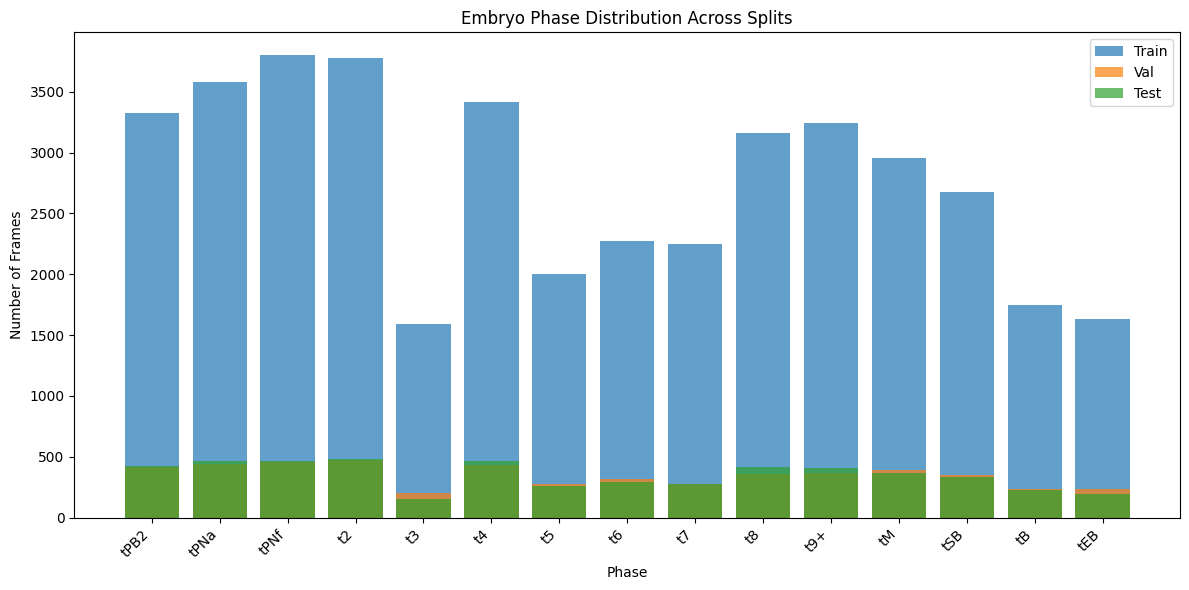

In [9]:
# 🧮 Class Distribution Visualization
from collections import Counter
import matplotlib.pyplot as plt

# Count samples per class
train_counts = Counter([lbl for _, lbl in train_ds.samples])
val_counts = Counter([lbl for _, lbl in val_ds.samples])
test_counts = Counter([lbl for _, lbl in test_ds.samples])

# Create a DataFrame for visualization
phase_names = [IDX2PHASE[i] for i in range(NUM_CLASSES)]
df_counts = pd.DataFrame({
    'Phase': phase_names,
    'Train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Val': [val_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Test': [test_counts.get(i, 0) for i in range(NUM_CLASSES)]
})

display(df_counts)

# Plot distributions
plt.figure(figsize=(12, 6))
plt.bar(df_counts['Phase'], df_counts['Train'], label='Train', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Val'], label='Val', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Test'], label='Test', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Phase')
plt.ylabel('Number of Frames')
plt.title('Embryo Phase Distribution Across Splits')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# 🧾 Embryo IDs per class (per split and overall)

from collections import defaultdict

def collect_embryo_ids_per_class(dataset):
    phase_to_ids = defaultdict(set)  # {label_idx: set(embryo_ids)}
    for path, lbl in dataset.samples:
        eid = path.parent.name  # folder name is the embryo id
        phase_to_ids[lbl].add(eid)
    return phase_to_ids

train_ids = collect_embryo_ids_per_class(train_ds)
val_ids   = collect_embryo_ids_per_class(val_ds)
test_ids  = collect_embryo_ids_per_class(test_ds)

# Build "overall" as the union across splits
overall_ids = defaultdict(set)
for i in range(NUM_CLASSES):
    overall_ids[i] = set().union(train_ids.get(i, set()),
                                 val_ids.get(i, set()),
                                 test_ids.get(i, set()))

def print_ids(title, mapping):
    print(f"\n=== {title} ===")
    for i, phase in enumerate(PHASES):
        ids = sorted(mapping.get(i, set()))
        print(f"{phase} [{len(ids)} embryos]: {', '.join(ids) if ids else '-'}")

#print_ids("TRAIN embryo IDs per class", train_ids)
#print_ids("VAL embryo IDs per class",   val_ids)
#print_ids("TEST embryo IDs per class",  test_ids)
#print_ids("OVERALL embryo IDs per class (union)", overall_ids)


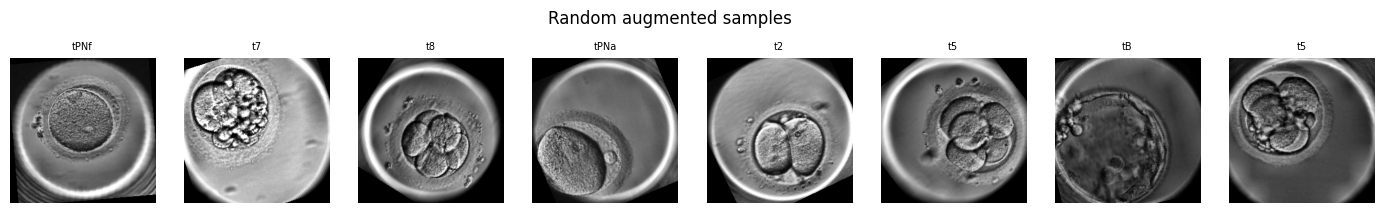

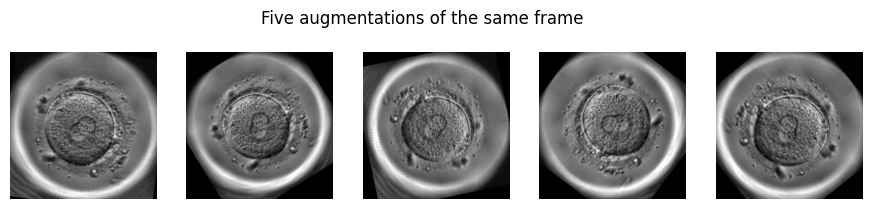

In [11]:
# @title 🔍 Preview data‐augmentations
import random, matplotlib.pyplot as plt
import torch

# -----------------------------------------------
# helper to de-normalise a 1×H×W tensor
def denorm(x):
    return (x*0.5 + 0.5).clamp(0,1).squeeze().cpu().numpy()

# 1)  Eight random augmented frames ----------------
N = 8
idxs = random.sample(range(len(train_ds)), N)
fig, axes = plt.subplots(1, N, figsize=(2.2*N, 2.5))

for ax, i in zip(axes, idxs):
    img, lbl = train_ds[i]
    ax.imshow(denorm(img), cmap='gray')
    ax.set_title(IDX2PHASE[lbl.item()], fontsize=7)
    ax.axis('off')
fig.suptitle("Random augmented samples", fontsize=12)
plt.show()

# 2)  Same frame, 5 different augmentations --------
idx = random.choice(range(len(train_ds)))
base_path, _ = train_ds.samples[idx]
base_img = Image.open(base_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
for ax in axes:
    aug = train_tfm(base_img)
    ax.imshow(denorm(aug), cmap='gray')
    ax.axis('off')
fig.suptitle("Five augmentations of the same frame", fontsize=12)
plt.show()


In [12]:
# @title 🧠 Model (EfficientNet-V2-S backbone + timestep-conditioned head)
import sys; sys.path.insert(0, '../diffusion')
from torchvision.models import EfficientNet_V2_S_Weights
from models import EfficientNetV2MGray

n_classes = train_ds.num_classes
model = EfficientNetV2MGray(
    n_classes=n_classes, time_dim=32, max_timesteps=1000,
    weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1,
    backbone="efficientnet_v2_s",
    dropout=0.3,
)
model.to(device)

BASE_LR = 2e-4

# Class-balanced CE (effective number of samples)
CB_BETA = 0.9999
cls_counts = np.array([class_counts.get(i, 0) for i in range(n_classes)], dtype=np.float64)
effective_num = 1.0 - np.power(CB_BETA, np.maximum(cls_counts, 1.0))
class_weights = (1.0 - CB_BETA) / effective_num
class_weights = class_weights / class_weights.sum() * n_classes
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

In [13]:
MIXUP_ALPHA, MIXUP_PROB = 0.6, 0.5
def apply_mixup(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0 or x.size(0) < 2: return x, (y, None, 1.0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], (y, y[idx], lam)

In [14]:
EPOCHS = 1000
PATIENCE = 10  # Early stopping patience (macro F1)
WARMUP_EPOCHS = 5  # Linear warmup epochs (backbone frozen)
FREEZE_EPOCHS = 5  # Freeze backbone for these initial epochs

# DDPM corruption settings (match diffusion): scaled_linear beta schedule, T=1000
TIMESTEPS = 1000
BETA_START, BETA_END = 1e-4, 2e-2
BETA_SCHEDULE = "scaled_linear"

betas = torch.linspace(BETA_START ** 0.5, BETA_END ** 0.5, TIMESTEPS, device=device, dtype=torch.float32) ** 2

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
P_NOISY = 0.3

# Non-uniform timestep policy (dynamic with TIMESTEPS)
TIMESTEP_BIN_PROBS = [0.70, 0.25, 0.05]
_edge1 = max(1, int(round(0.30 * TIMESTEPS)))
_edge2 = max(_edge1 + 1, int(round(0.70 * TIMESTEPS)))
TIMESTEP_BIN_EDGES = [0, _edge1, _edge2, TIMESTEPS]

# Noisy evaluation timesteps (fractions of full schedule)
NOISY_EVAL_TS = sorted(set([int((TIMESTEPS - 1) * q) for q in (0.1, 0.3, 0.5, 0.7, 0.9)]))

def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return sqrt_alpha * x0 + sqrt_one_minus * noise

def sample_timesteps_nonuniform(batch_size: int):
    bins = torch.multinomial(torch.tensor(TIMESTEP_BIN_PROBS, device=device, dtype=torch.float32), batch_size, replacement=True)
    t = torch.empty(batch_size, device=device, dtype=torch.long)
    low0, high0 = TIMESTEP_BIN_EDGES[0], TIMESTEP_BIN_EDGES[1]
    low1, high1 = TIMESTEP_BIN_EDGES[1], TIMESTEP_BIN_EDGES[2]
    low2, high2 = TIMESTEP_BIN_EDGES[2], TIMESTEP_BIN_EDGES[3]
    m0 = bins == 0
    m1 = bins == 1
    m2 = bins == 2
    if m0.any():
        t[m0] = torch.randint(low0, high0, (int(m0.sum().item()),), device=device)
    if m1.any():
        t[m1] = torch.randint(low1, high1, (int(m1.sum().item()),), device=device)
    if m2.any():
        t[m2] = torch.randint(low2, high2, (int(m2.sum().item()),), device=device)
    return t

# --- Phase 1: freeze backbone, train head only with linear warmup ---
from torch.optim.lr_scheduler import ReduceLROnPlateau, LinearLR

for p in model.base.parameters():
    p.requires_grad = False

head_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(head_params, lr=BASE_LR, weight_decay=3e-4)
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
plateau_sched = None

# Mixed precision for speed
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

best_f1 = -1.0
best_state = None
epochs_no_improve = 0
loss_history = []
f1_history = []

for epoch in range(1, EPOCHS+1):
    # --- Phase 2: unfreeze backbone with differential LR ---
    if epoch == FREEZE_EPOCHS + 1:
        print(f"\n>>> Unfreezing backbone at epoch {epoch} with 10x lower LR <<<\n")
        for p in model.base.parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW([
            {"params": model.base.parameters(), "lr": BASE_LR / 10},
            {"params": list(model.time_embed.parameters()) +
                       list(model.time_mlp.parameters()) +
                       list(model.classifier.parameters()), "lr": BASE_LR},
        ], weight_decay=3e-4)
        plateau_sched = ReduceLROnPlateau(
            optimizer, mode="max", factor=0.8, patience=4, min_lr=1e-7
        )
        epochs_no_improve = 0  # reset after phase change

    # --- train ---
    model.train()
    tr_loss = 0.0
    tr_hits = 0.0
    tr_count = 0
    for xb, yb in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        y1, y2, lam = yb, yb, 1.0
        do_mixup = np.random.rand() < MIXUP_PROB
        if do_mixup:
            xb, (y1, y2, lam) = apply_mixup(xb, yb)

        # Clean + noisy mix (p_noisy controls per-sample corruption)
        t_batch = torch.zeros(xb.size(0), device=device, dtype=torch.long)
        noisy_mask = torch.rand(xb.size(0), device=device) < P_NOISY
        if noisy_mask.any():
            t_noisy = sample_timesteps_nonuniform(int(noisy_mask.sum().item()))
            xb_noisy = q_sample(xb[noisy_mask], t_noisy)
            xb = xb.clone()
            xb[noisy_mask] = xb_noisy
            t_batch[noisy_mask] = t_noisy
        
        with torch.autocast(device_type='cuda', enabled=use_amp):
            logits = model(xb, t_batch)
            if do_mixup:
                loss = lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)
            else:
                loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item() * xb.size(0)
        preds = logits.argmax(1)
        if do_mixup:
            tr_hits += (preds == y1).float().sum().item() * lam
            tr_hits += (preds == y2).float().sum().item() * (1 - lam)
        else:
            tr_hits += (preds == yb).sum().item()
        tr_count += xb.size(0)
    tr_loss /= len(train_ds)
    tr_acc = (tr_hits / tr_count) if tr_count > 0 else float('nan')

    # --- val ---
    model.eval()
    val_loss = 0.0
    val_hits = 0
    val_preds = []
    val_trues = []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            t_val = torch.zeros(xb.size(0), device=device, dtype=torch.long)
            logits = model(xb, t_val)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(1)
            val_hits += (preds == yb).sum().item()
            val_preds.extend(preds.cpu().numpy())
            val_trues.extend(yb.cpu().numpy())
    val_loss /= len(val_ds)
    val_acc = val_hits / len(val_ds)
    val_f1 = f1_score(val_trues, val_preds, average="macro", zero_division=0)

    # LR scheduling
    if epoch <= WARMUP_EPOCHS:
        warmup_sched.step()
    elif plateau_sched is not None:
        plateau_sched.step(val_f1)

    if epoch <= FREEZE_EPOCHS:
        lr_str = f"lr {optimizer.param_groups[0]['lr']:.2e} (backbone frozen)"
    else:
        lr_str = f"lr_bb {optimizer.param_groups[0]['lr']:.2e} lr_head {optimizer.param_groups[1]['lr']:.2e}"

    print(f"[{epoch:02d}] train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} f1 {val_f1:.3f} | {lr_str}")
    loss_history.append((tr_loss, val_loss))
    f1_history.append(val_f1)

    # --- early stop on macro F1 ---
    if val_f1 > best_f1 + 1e-4:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"\t*** New best! Val F1: {val_f1:.4f} ***")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping after {epochs_no_improve} epochs.")
            break

# load best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

Epoch 1/1000:   0%|          | 0/1295 [00:00<?, ?it/s]

KeyboardInterrupt: 

Eval t=clean:   0%|          | 0/164 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        tPB2      0.795     0.905     0.846       420
        tPNa      0.851     0.721     0.781       469
        tPNf      0.649     0.835     0.731       466
          t2      0.798     0.784     0.791       485
          t3      0.388     0.494     0.434       154
          t4      0.701     0.599     0.646       469
          t5      0.389     0.475     0.428       263
          t6      0.445     0.376     0.407       290
          t7      0.328     0.225     0.267       276
          t8      0.601     0.585     0.593       417
         t9+      0.701     0.641     0.670       410
          tM      0.640     0.757     0.693       366
         tSB      0.692     0.684     0.688       332
          tB      0.568     0.525     0.545       223
         tEB      0.663     0.629     0.646       194

    accuracy                          0.648      5234
   macro avg      0.614     0.616     0.611      5234
weighted avg      0.648   

Eval t=clean:   0%|          | 0/164 [00:00<?, ?it/s]

VAL clean: 0.5972


Eval t=99:   0%|          | 0/164 [00:00<?, ?it/s]

...

TEST t= 499: 0.3937


Eval t=699:   0%|          | 0/164 [00:00<?, ?it/s]

TEST t= 699: 0.1228


Eval t=899:   0%|          | 0/164 [00:00<?, ?it/s]

TEST t= 899: 0.0361


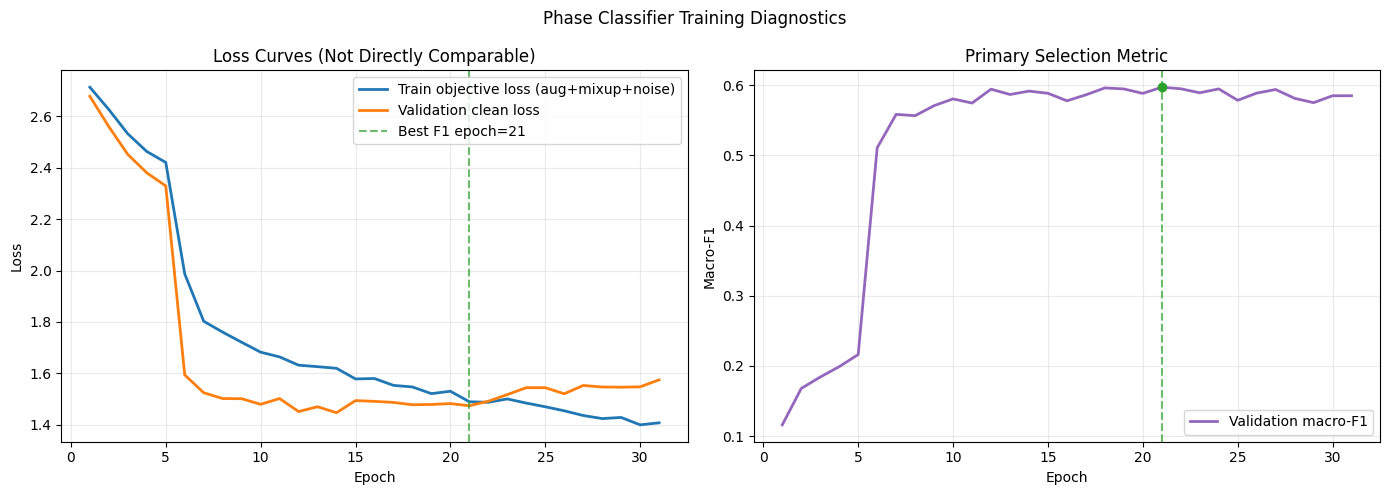

In [ ]:
# @title 📊 Val/Test Report (clean + noisy-by-t)
model.eval()

def eval_loader_macro_f1(loader, t_eval: int | None = None):
    preds, trues = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Eval t={t_eval if t_eval is not None else 'clean'}", leave=False):
            x, y = x.to(device), y.to(device)
            if t_eval is not None:
                t_vec = torch.full((x.size(0),), int(t_eval), device=device, dtype=torch.long)
                x = q_sample(x, t_vec)
            else:
                t_vec = torch.zeros(x.size(0), device=device, dtype=torch.long)
            logits = model(x, t_vec)
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    f1 = f1_score(trues, preds, average="macro", zero_division=0)
    return f1, preds, trues

# Clean TEST classification report (kept for compatibility)
test_clean_f1, test_preds, test_trues = eval_loader_macro_f1(test_dl, t_eval=None)
unique_labels = sorted(list(set(test_trues)))
target_names = [IDX2PHASE[i] for i in unique_labels]
report = classification_report(test_trues, test_preds, labels=unique_labels, target_names=target_names, digits=3)
print(report)
cm = confusion_matrix(test_trues, test_preds, labels=unique_labels)
print("Confusion matrix\n", cm)

# Noisy-by-t macro F1 for VAL and TEST
print("\nMacro-F1 by noise level (clean + noisy):")
for split_name, loader in [("VAL", val_dl), ("TEST", test_dl)]:
    f1_clean, _, _ = eval_loader_macro_f1(loader, t_eval=None)
    print(f"{split_name} clean: {f1_clean:.4f}")
    for t_eval in NOISY_EVAL_TS:
        f1_noisy, _, _ = eval_loader_macro_f1(loader, t_eval=t_eval)
        print(f"{split_name} t={t_eval:4d}: {f1_noisy:.4f}")

# Training diagnostics figure (clearer than raw train-vs-val loss only)
train_losses, val_losses = zip(*loss_history)
epochs = np.arange(1, len(loss_history) + 1)
best_epoch = int(np.argmax(f1_history)) + 1 if len(f1_history) else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train objective loss (aug+mixup+noise)', linewidth=2)
axes[0].plot(epochs, val_losses, label='Validation clean loss', linewidth=2)
if best_epoch is not None:
    axes[0].axvline(best_epoch, color='tab:green', linestyle='--', alpha=0.7, label=f'Best F1 epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (Not Directly Comparable)')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, f1_history, color='tab:purple', label='Validation macro-F1', linewidth=2)
if best_epoch is not None:
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', alpha=0.7)
    axes[1].scatter([best_epoch], [f1_history[best_epoch - 1]], color='tab:green', zorder=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-F1')
axes[1].set_title('Primary Selection Metric')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle('Phase Classifier Training Diagnostics', fontsize=12)
fig.tight_layout()
plt.show()


In [ ]:

# @title 💾 Save Model
import datetime, torch
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"embryo_phase_models/phase_classifier_{timestamp}.pth"
config = {
    "model_name": "efficientnet_v2_s_gray",
    "backbone": "efficientnet_v2_s",
    "dropout": 0.3,
    "img_size": IMG_SIZE,
    "focal_planes": FOCAL_PLANES,
    "phases": PHASES,
    "phase_alias": PHASE_ALIAS,
    "label_smoothing": 0.1,
    "mixup_alpha": MIXUP_ALPHA,
    "mixup_prob": MIXUP_PROB,
    "frames_per_phase": FRAMES_PER_PHASE,
    "timesteps": TIMESTEPS,
    "beta_start": BETA_START,
    "beta_end": BETA_END,
    "beta_schedule": BETA_SCHEDULE,
    "p_noisy": P_NOISY,
    "timestep_bin_probs": TIMESTEP_BIN_PROBS,
    "timestep_bin_edges": TIMESTEP_BIN_EDGES,
    "noisy_eval_ts": NOISY_EVAL_TS,
    "time_conditioned": True,
    "time_emb_dim": 32,
    "warmup_epochs": WARMUP_EPOCHS,
    "freeze_epochs": FREEZE_EPOCHS,
    "base_lr": BASE_LR,
}
torch.save({"model_state_dict": model.state_dict(), "config": config}, out_path)
print("Model saved to", out_path)

Model saved to embryo_phase_models/phase_classifier_20260424_233258.pth
